# Waveform PCA scree and PC-space clustering

Castellucci et al. (*Cell Reports* 2025) Figure 1D–E style, on the **insula concat-NMF** waveform matrix.

Compute (Slurm, tables only):

```bash
sbatch scripts/slurm/nmf_pc_clustering.sh
```

This notebook **only reads** `results/nmf/pc_*.csv` / `rank_selection_metrics.csv` and writes SVGs under `img/nmf/`.
It does not refit NMF and does not overwrite `channel_assignments.csv`.

HGA traces / heatmap are the exception: they load packaged Repeat HGA. Run that cell on a compute node, not the login node.

- **1D / 1E:** their rank-selection rule in PC space (scree; silhouette and Calinski–Harabasz vs *k*).
- **NMF rank:** cophenetic, bootstrap ARI, cosine silhouette, and reconstruction error vs *k* — this is the justification for canonical *k*=3.
- **Scatter comparison:** same PC1–PC2 scatter, colored by k-means at NMF *k*=3 after matching onto NMF names.
- **UMAP check:** unsupervised 2-D layout of the stored PCs, colored by frozen NMF labels (does not overwrite assignments).
- **HGA traces / heatmap:** empirical Repeat HGA on the same 255 electrodes (exclude list + D0121 already dropped).
- **Spatial brains:** Gaussian cluster density + electrodes, phases as columns (no Go).
- **Laterality:** implanted AIC/PIC coverage (not significance-filtered) vs NMF labels; loading distributions (mean / p90 / max); subject-level LI; HGA traces split by hemisphere.
- Vertical dashed line: *k* that maximises k-means median silhouette (their rule).
- Dotted line: canonical NMF *k*=3, for comparison only.

Figure style follows [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md): sizes in cm, 7 pt type.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.nmf.waveform_analysis import CLUSTER_ORDER, FUNCTION_COLORS, ordered_clusters
from src.paths import img_dir, nmf_results_dir, save_svg

cm = 1 / 2.54
plt.rcParams["svg.fonttype"] = "none"
fontsize = 7
fontdict = {"fontsize": fontsize}

NMF_K = 3
RESULTS = nmf_results_dir()
IMG = img_dir("nmf")

red = "#A9373B"
blue = "#2369BD"
gold = "#C4A35A"

METHOD_COLORS = {
    "kmeans": "#333333",
    "kmedoids": red,
    "gmm": blue,
    "ward": gold,
}
METHOD_LABELS = {
    "kmeans": "k-means",
    "kmedoids": "k-medoids",
    "gmm": "Gaussian mixture",
    "ward": "Ward",
}


def style_ax(ax, *, trim=True):
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=trim)


In [2]:
import json

scree = pd.read_csv(RESULTS / "pc_scree.csv")
metrics = pd.read_csv(RESULTS / "pc_clustering_metrics.csv")
scores = pd.read_csv(RESULTS / "pc_scores.csv")
meta = json.loads((RESULTS / "pc_clustering_meta.json").read_text(encoding="utf-8"))

n_embed = int(meta["n_embedding_pcs"])
k_sil = int(meta["k_silhouette"]["k"])
k_ch = int(meta["k_calinski"]["k"])

print(f"electrodes={meta['n_electrodes']}  features={meta['n_features']}")
print(f"embedding PCs (>{100 * meta['variance_threshold']:.0f}% each): {n_embed}")
print("explained:", [f"{100 * v:.1f}%" for v in meta["explained_variance_ratio"][:n_embed]])
print(f"k-means max silhouette → k={k_sil}")
print(f"k-means max Calinski–Harabasz → k={k_ch}")
metrics


electrodes=255  features=444
embedding PCs (>5% each): 3
explained: ['27.4%', '11.5%', '5.6%']
k-means max silhouette → k=2
k-means max Calinski–Harabasz → k=2


,method,k,n_runs,silhouette_median,silhouette_iqr,calinski_median,calinski_iqr
0,gmm,2,500,0.325964,0.000000,155.261716,0.000000e+00
1,gmm,3,500,0.332508,0.000000,156.526826,2.842171e-14
2,gmm,4,500,0.268278,0.013679,156.968254,3.013521e+01
3,gmm,5,500,0.241699,0.040749,127.800752,3.364245e+01
4,gmm,6,500,0.245307,0.027237,127.573940,2.290679e+01
5,gmm,7,500,0.237591,0.033391,124.316243,2.092539e+01
6,gmm,8,500,0.230375,0.033330,118.743488,1.795067e+01
7,gmm,9,500,0.230698,0.030493,118.027185,1.679011e+01
8,gmm,10,500,0.230629,0.032185,116.886621,1.436493e+01
9,kmeans,2,500,0.413104,0.000344,228.308623,3.290241e-02


## Figure 1D — PC variance


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/pca_variance.svg


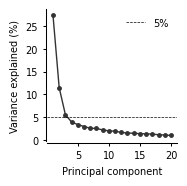

In [3]:
fig, ax = plt.subplots(figsize=(5 * cm, 5 * cm))
ax.plot(
    scree["pc"],
    100 * scree["explained_variance_ratio"],
    "o-",
    color="#333333",
    lw=1,
    ms=2.5,
)
ax.axhline(5.0, color="k", ls="--", lw=0.5, label="5%")
ax.set_xlabel("Principal component", **fontdict)
ax.set_ylabel("Variance explained (%)", **fontdict)
ax.set_xticks(list(range(5, int(scree["pc"].max()) + 1, 5)))
style_ax(ax, trim=False)
ax.legend(frameon=False, fontsize=fontsize)
fig.tight_layout()
save_svg(fig, IMG / "pca_variance.svg", close=False)
print("Wrote", IMG / "pca_variance.svg")

## Figure 1E — silhouette and Calinski–Harabasz vs *k*

Median over 500 random initialisations for k-means, k-medoids, and GMM. Ward is deterministic.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/pc_cluster_metrics.svg


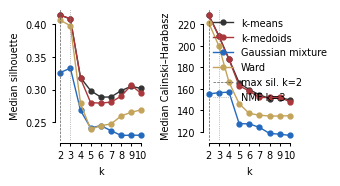

In [4]:
def _plot_metric(ax, column, ylabel):
    for method, color in METHOD_COLORS.items():
        sub = metrics.loc[metrics["method"].eq(method)].sort_values("k")
        if sub.empty:
            continue
        ax.plot(
            sub["k"],
            sub[column],
            "o-",
            color=color,
            lw=1,
            ms=3.5,
            label=METHOD_LABELS[method],
        )
    ax.axvline(k_sil, color="0.35", ls="--", lw=0.5, label=f"max sil. k={k_sil}")
    ax.axvline(NMF_K, color="0.55", ls=":", lw=0.5, label=f"NMF k={NMF_K}")
    ax.set_xlabel("k", **fontdict)
    ax.set_ylabel(ylabel, **fontdict)
    ax.set_xticks(sorted(metrics["k"].unique()))
    style_ax(ax)


fig, axes = plt.subplots(1, 2, figsize=(8 * cm, 5 * cm))
_plot_metric(axes[0], "silhouette_median", "Median silhouette")
_plot_metric(axes[1], "calinski_median", "Median Calinski–Harabasz")
axes[1].legend(frameon=False, fontsize=fontsize, loc="best")
fig.tight_layout()
save_svg(fig, IMG / "pc_cluster_metrics.svg", close=False)
print("Wrote", IMG / "pc_cluster_metrics.svg")

## NMF rank metrics — justifying *k*=3

Same concat matrix as the canonical NMF fit. Primary: cophenetic correlation of the electrode-bootstrap consensus (the rule in `chosen_k.json`). Also shown: mean pairwise bootstrap ARI, cosine silhouette of NMF hard labels on `X`, and reconstruction error \(\|X-WH\|_F\).

Cophenetic / ARI peak at *k*=3. Cosine silhouette is slightly higher at *k*=2 and collapses at *k*≥4. Reconstruction always falls with *k*; the elbow is the kneedle point (maximum deviation from the chord joining the first and last *k*). These curves select the NMF rank; the PC-space panel above does not.


 k  cophenetic  mean_ari  silhouette_cosine  reconstruction_error
 2    0.998463  0.974957           0.336291              9.085913
 3    0.998703  0.980255           0.318636              8.348479
 4    0.988076  0.890054           0.153605              7.984807
 5    0.953993  0.690107           0.111489              7.740961
 6    0.965996  0.710678           0.097783              7.498561
chosen k=3  rule=max_cophenetic  near-ties=[2, 3, 4]
reconstruction drop:
  2→3: 0.737
  3→4: 0.364
  4→5: 0.244
  5→6: 0.242
kneedle elbow (recon): k=3
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/nmf_rank_k.svg


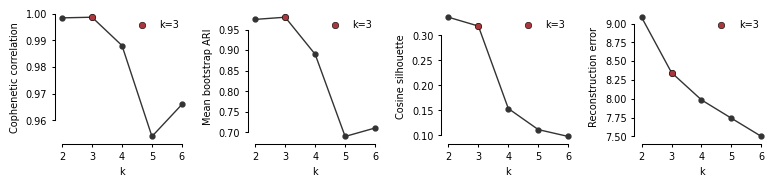

In [19]:
import json

rank = pd.read_csv(RESULTS / "rank_selection_metrics.csv")
chosen = json.loads((RESULTS / "chosen_k.json").read_text(encoding="utf-8"))
k_nmf = int(chosen["k"])
ks = rank["k"].to_numpy(int)
err = rank["reconstruction_error"].to_numpy(float)


def kneedle_decreasing(k, y):
    """Elbow = max deviation below the chord from first to last k (kneedle)."""
    k = np.asarray(k, dtype=float)
    y = np.asarray(y, dtype=float)
    x = (k - k.min()) / (k.max() - k.min())
    yn = (y - y.min()) / (y.max() - y.min())
    chord = yn[0] + (yn[-1] - yn[0]) * x
    idx = int(np.argmax(chord - yn))
    return int(k[idx])


k_elbow = kneedle_decreasing(ks, err)
delta = -np.diff(err)
print(
    rank[
        ["k", "cophenetic", "mean_ari", "silhouette_cosine", "reconstruction_error"]
    ].to_string(index=False)
)
print(f"chosen k={k_nmf}  rule={chosen['rule']}  near-ties={chosen['near_tie_ks']}")
print("reconstruction drop:")
for k0, k1, d in zip(ks[:-1], ks[1:], delta):
    print(f"  {k0}→{k1}: {d:.3f}")
print(f"kneedle elbow (recon): k={k_elbow}")

panels = (
    ("cophenetic", "Cophenetic correlation"),
    ("mean_ari", "Mean bootstrap ARI"),
    ("silhouette_cosine", "Cosine silhouette"),
    ("reconstruction_error", "Reconstruction error"),
)
fig, axes = plt.subplots(1, 4, figsize=(20 * cm, 5 * cm), sharex=True)
for ax, (col, ylabel) in zip(axes, panels):
    ax.plot(rank["k"], rank[col], "o-", color="#333333", lw=1, ms=3.5, zorder=2)
    y_star = float(rank.loc[rank["k"].eq(k_nmf), col].iloc[0])
    ax.scatter(
        [k_nmf],
        [y_star],
        s=22,
        color=red,
        edgecolor="black",
        linewidth=0.4,
        zorder=3,
        label=f"k={k_nmf}",
    )
    ax.set_xlabel("k", **fontdict)
    ax.set_ylabel(ylabel, **fontdict)
    ax.set_xticks(sorted(ks.tolist()))
    style_ax(ax)
    ax.legend(frameon=False, fontsize=fontsize, loc="best")
fig.tight_layout()
save_svg(fig, IMG / "nmf_rank_k.svg", close=False)
print("Wrote", IMG / "nmf_rank_k.svg")

## Sanity check — k-means *k*=3, matched to NMF

PC1–PC2 scatter colored by k-means at NMF *k*=3 after Hungarian matching onto NMF names, with PC1 and PC2 marginal histograms on the corresponding axes.

Adjusted Rand index and the NMF × k-means table are printed below the figure.


ARI  NMF vs k-means k=3: 0.749
NMF × matched k-means k=3
kmeans_k3           sustain  motor  sensory
functional_cluster                         
sustain                  73      0        1
motor                    16    123        3
sensory                   1      0       38
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/waveform_pca_kmeans.svg


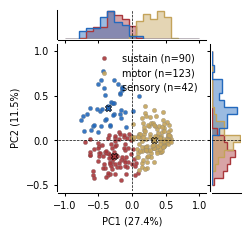

In [6]:
from matplotlib.ticker import MultipleLocator
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

embed = scores[[f"PC{i}" for i in range(1, n_embed + 1)]].to_numpy(float)
nmf = scores["functional_cluster"].astype(str)
explained = np.asarray(meta["explained_variance_ratio"], dtype=float)
rng = int(meta["random_state"])

km3 = KMeans(n_clusters=NMF_K, n_init=50, random_state=rng).fit_predict(embed)
nmf_names = ordered_clusters(nmf)
conf = pd.crosstab(pd.Series(km3), nmf).reindex(columns=nmf_names, fill_value=0)
rows, cols = linear_sum_assignment(-conf.to_numpy(float))
km3_to_name = {int(conf.index[r]): nmf_names[c] for r, c in zip(rows, cols)}
km3_named = np.array([km3_to_name[int(v)] for v in km3])

print(f"ARI  NMF vs k-means k={NMF_K}: {adjusted_rand_score(nmf, km3):.3f}")
print("NMF × matched k-means k=3")
print(pd.crosstab(nmf, pd.Series(km3_named, name="kmeans_k3")).reindex(index=nmf_names, columns=nmf_names))

x = scores["PC1"].to_numpy(float)
y = scores["PC2"].to_numpy(float)
x_bins = np.linspace(np.floor(x.min() / 0.5) * 0.5, np.ceil(x.max() / 0.5) * 0.5, 20)
y_bins = np.linspace(np.floor(y.min() / 0.5) * 0.5, np.ceil(y.max() / 0.5) * 0.5, 20)

fig = plt.figure(figsize=(6 * cm, 6 * cm))
grid = fig.add_gridspec(
    2,
    2,
    width_ratios=(5.0, 1),
    height_ratios=(1, 5.0),
    wspace=0.06,
    hspace=0.06,
)
ax_histx = fig.add_subplot(grid[0, 0])
ax = fig.add_subplot(grid[1, 0], sharex=ax_histx)
ax_histy = fig.add_subplot(grid[1, 1], sharey=ax)

for cluster in nmf_names:
    mask = km3_named == cluster
    color = FUNCTION_COLORS.get(cluster, "0.4")
    ax.scatter(
        x[mask],
        y[mask],
        s=10,
        color=color,
        edgecolor="gray",
        linewidth=0.2,
        alpha=0.9,
        label=f"{cluster} (n={int(mask.sum())})",
    )
    ax.scatter(
        x[mask].mean(),
        y[mask].mean(),
        s=20,
        marker="X",
        color=color,
        edgecolor="black",
        linewidth=0.5,
        zorder=3,
    )
    ax_histx.hist(
        x[mask],
        bins=x_bins,
        density=True,
        histtype="stepfilled",
        color=color,
        alpha=0.45,
        linewidth=0,
    )
    ax_histx.hist(x[mask], bins=x_bins, density=True, histtype="step", color=color, linewidth=1)
    ax_histy.hist(
        y[mask],
        bins=y_bins,
        density=True,
        histtype="stepfilled",
        orientation="horizontal",
        color=color,
        alpha=0.45,
        linewidth=0,
    )
    ax_histy.hist(
        y[mask],
        bins=y_bins,
        density=True,
        histtype="step",
        orientation="horizontal",
        color=color,
        linewidth=1,
    )

ax.set_xlabel(f"PC1 ({100 * explained[0]:.1f}%)", **fontdict)
ax.set_ylabel(f"PC2 ({100 * explained[1]:.1f}%)", **fontdict)
ax.axhline(0.0, color="k", linestyle="--", linewidth=0.5)
ax.axvline(0.0, color="k", linestyle="--", linewidth=0.5)
ax_histx.axvline(0.0, color="k", linestyle="--", linewidth=0.5)
ax_histy.axhline(0.0, color="k", linestyle="--", linewidth=0.5)
style_ax(ax, trim=False)
style_ax(ax_histx, trim=False)
style_ax(ax_histy, trim=False)
ax.xaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax_histx.tick_params(labelbottom=False, labelleft=False, left=False)
ax_histx.set_yticks([])
ax_histy.tick_params(labelleft=False, labelbottom=False, bottom=False)
ax_histy.set_xticks([])
ax.legend(frameon=False, fontsize=fontsize, loc="best")
save_svg(fig, IMG / "waveform_pca_kmeans.svg", close=False)
print("Wrote", IMG / "waveform_pca_kmeans.svg")

## Sanity check — UMAP of the waveform PCs

Unsupervised UMAP on the 20 stored PCs (~78% variance), **not** a new clustering.
The same 2-D coordinates are colored by frozen NMF labels (left) and by k-means *k*=3 matched onto NMF names (right).

If the three NMF groups are discrete islands, they should form separate blobs on the left without using the labels in the embedding. A continuum with motor in the middle is also a possible outcome.

`n_neighbors=15`, `min_dist=0.1`, Euclidean metric, `random_state` from the PCA tables. Does not overwrite `channel_assignments.csv`.


/hpc/home/ns458/.local/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP on 20 PCs (78.0% variance), n=255
NMF silhouette in UMAP 2-D:     0.449
k-means silhouette in UMAP 2-D: 0.480
NMF silhouette in PC1–PC2:      0.481
ARI NMF vs k-means k=3:     0.749
Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/waveform_umap.svg


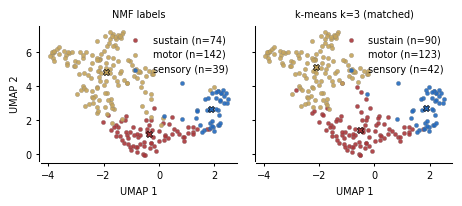

In [7]:
import os
from pathlib import Path

_numba_cache = Path("/hpc/group/coganlab/nanlinshi/.cache/numba")
_numba_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("NUMBA_CACHE_DIR", str(_numba_cache))

import umap
from matplotlib.ticker import MaxNLocator
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

pc_cols = [col for col in scores.columns if col.startswith("PC")]
X_umap = scores[pc_cols].to_numpy(float)
embed = scores[[f"PC{i}" for i in range(1, n_embed + 1)]].to_numpy(float)
nmf = scores["functional_cluster"].astype(str)
nmf_names = ordered_clusters(nmf)
explained = np.asarray(meta["explained_variance_ratio"], dtype=float)
rng = int(meta["random_state"])

km3 = KMeans(n_clusters=NMF_K, n_init=50, random_state=rng).fit_predict(embed)
conf = pd.crosstab(pd.Series(km3), nmf).reindex(columns=nmf_names, fill_value=0)
rows, cols = linear_sum_assignment(-conf.to_numpy(float))
km3_to_name = {int(conf.index[r]): nmf_names[c] for r, c in zip(rows, cols)}
km3_named = np.array([km3_to_name[int(v)] for v in km3])

xy = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=rng,
).fit_transform(X_umap)

print(
    f"UMAP on {X_umap.shape[1]} PCs "
    f"({100 * explained[: len(pc_cols)].sum():.1f}% variance), n={len(scores)}"
)
print(f"NMF silhouette in UMAP 2-D:     {silhouette_score(xy, nmf):.3f}")
print(f"k-means silhouette in UMAP 2-D: {silhouette_score(xy, km3_named):.3f}")
print(f"NMF silhouette in PC1–PC2:      {silhouette_score(scores[['PC1', 'PC2']], nmf):.3f}")
print(f"ARI NMF vs k-means k={NMF_K}:     {adjusted_rand_score(nmf, km3):.3f}")


def scatter_umap(ax, labels, title):
    for cluster in nmf_names:
        mask = labels == cluster
        color = FUNCTION_COLORS.get(cluster, "0.4")
        ax.scatter(
            xy[mask, 0],
            xy[mask, 1],
            s=10,
            color=color,
            edgecolor="gray",
            linewidth=0.2,
            alpha=0.9,
            label=f"{cluster} (n={int(mask.sum())})",
        )
        ax.scatter(
            xy[mask, 0].mean(),
            xy[mask, 1].mean(),
            s=20,
            marker="X",
            color=color,
            edgecolor="black",
            linewidth=0.5,
            zorder=3,
        )
    ax.set_title(title, **fontdict)
    ax.set_xlabel("UMAP 1", **fontdict)
    ax.set_ylabel("UMAP 2", **fontdict)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(4))
    style_ax(ax, trim=False)
    ax.legend(frameon=False, fontsize=fontsize, loc="best")


fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 5.5 * cm), sharex=True, sharey=True)
scatter_umap(axes[0], nmf.to_numpy(), "NMF labels")
scatter_umap(axes[1], km3_named, "k-means k=3 (matched)")
axes[1].set_ylabel("")
fig.tight_layout()
save_svg(fig, IMG / "waveform_umap.svg", close=False)
print("Wrote", IMG / "waveform_umap.svg")


## Empirical HGA traces and heatmap

Same 255 concat-NMF electrodes as the PCA/UMAP cells: canonical `channel_assignments.csv`, minus `exclude_channels.txt` and D0121. Tasks match NMF discovery (no LexicalNoDelay). Repeat / sound only.

The next cell **loads packaged HGA** — run on a compute node (`srun` / notebook on a job), not the login node. It does not overwrite assignments.


In [8]:
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

from plot_functional_hga_heatmap import PHASES, cluster_phase_channel_order, load_subset

hga, hga_meta = load_subset(NMF_K)
hga["cluster_label"] = hga["functional_cluster"].astype(str)
TRACE_CLUSTERS = [c for c in CLUSTER_ORDER if c in set(hga["functional_cluster"].astype(str))]
HEATMAP_CLUSTERS = [c for c in ("sensory", "sustain", "motor") if c in set(hga["functional_cluster"].astype(str))]
CLUSTER_CMAPS = {
    name: sns.light_palette(FUNCTION_COLORS[name], as_cmap=True) for name in TRACE_CLUSTERS
}
print("trace order:", TRACE_CLUSTERS)
print("heatmap row order:", HEATMAP_CLUSTERS)
print("n electrodes:", hga["channel"].nunique())


load HGA:   0%|          | 0/1723 [00:00<?, ?it/s]

/hpc/group/coganlab/nanlinshi/insula-functional/scripts/plot_functional_hga_heatmap.py:123: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/group/coganlab/nanlinshi/insula-functional/scripts/plot_functional_hga_heatmap.py:123: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/group/coganlab/nanlinshi/insula-functional/scripts/plot_functional_hga_heatmap.py:123: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/group/coganlab/nanlinshi/insula-functional/scripts/plot_functional_hga_heatmap.py:123: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/hpc/group/coganlab/nanlinshi/insula-functional/scripts/plot_functional_hga_heatmap.py:123: DtypeWarning: Columns (34) have mixe

functional_cluster
motor      142
sensory     39
sustain     74
Name: channel, dtype: int64
trace order: ['sustain', 'motor', 'sensory']
heatmap row order: ['sensory', 'sustain', 'motor']
n electrodes: 255


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/functional_hga_traces.svg


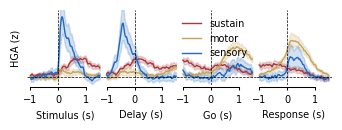

In [9]:
hue_order = TRACE_CLUSTERS
palette = [FUNCTION_COLORS[c] for c in TRACE_CLUSTERS]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(PHASES),
    figsize=(2.5 * len(PHASES) * cm, 2.5 * cm),
)
plt.subplots_adjust(wspace=0)

for ax, phase in zip(axes, PHASES):
    legend = ax is axes[-2]
    sns.lineplot(
        data=hga[hga.phase == phase],
        x="time",
        y="value",
        hue="cluster_label",
        hue_order=hue_order,
        ax=ax,
        palette=palette,
        legend=legend,
        lw=1,
    )
    ax.set_xlabel(f"{phase.capitalize()} (s)", fontsize=fontsize)

for ax in fig.axes:
    ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5)
    ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5)
    style_ax(ax, trim=True)
    if ax is axes[-2] and ax.get_legend() is not None:
        ax.legend(title="", fontsize=fontsize, frameon=False)
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
    ax.set_yticklabels([])
    ax.set_yticks([])
    ax.spines["left"].set_visible(False)
    ax.set_ylim(-0.1, 0.8)
    ax.set_ylabel("HGA (z)" if ax is axes[0] else "", fontsize=fontsize)

save_svg(fig, IMG / "functional_hga_traces.svg", close=False)
print("Wrote", IMG / "functional_hga_traces.svg")


Per-channel HGA heatmap: rows are NMF electrodes in each cluster, sorted by first significant time in that phase. Non-significant samples (`mask` False) are blank. Row order is sensory → sustain → motor.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/functional_hga_heatmap.svg


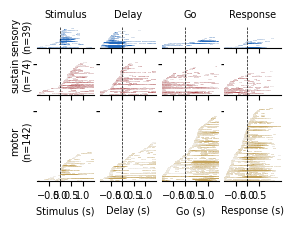

In [10]:
import xarray as xr

agg = (
    hga.groupby(["channel", "time", "phase", "functional_cluster"], as_index=False)
    .agg(value=("value", "mean"), mask=("mask", "any"))
)
agg.loc[~agg["mask"], "value"] = np.nan

n_by_cluster = {
    c: int(hga.loc[hga.functional_cluster == c, "channel"].nunique())
    for c in HEATMAP_CLUSTERS
}
height_ratios = [max(n_by_cluster.get(c, 0), 1) for c in HEATMAP_CLUSTERS]

fig = plt.figure(figsize=(2 * len(PHASES) * cm, 0.02 * sum(height_ratios) * cm))
gs = fig.add_gridspec(
    nrows=len(HEATMAP_CLUSTERS),
    ncols=len(PHASES),
    height_ratios=height_ratios,
    hspace=0.15,
    wspace=0.1,
)
axes = np.empty((len(HEATMAP_CLUSTERS), len(PHASES)), dtype=object)
for i in range(len(HEATMAP_CLUSTERS)):
    for j in range(len(PHASES)):
        sharex = axes[0, j] if i > 0 else None
        axes[i, j] = fig.add_subplot(gs[i, j], sharex=sharex)

for i, cluster in enumerate(HEATMAP_CLUSTERS):
    cmap = CLUSTER_CMAPS[cluster]
    for j, phase in enumerate(PHASES):
        ax = axes[i, j]
        ordered = cluster_phase_channel_order(agg, phase, cluster)
        phase_data = agg[
            (agg.phase == phase)
            & (agg.functional_cluster == cluster)
            & agg.channel.isin(ordered)
        ]
        if not ordered:
            ax.text(
                0.5,
                0.5,
                "No channels",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=fontsize,
            )
            ax.set_yticks([])
            continue

        pivot = (
            phase_data.pivot(index="channel", columns="time", values="value")
            .reindex(index=ordered)
        )
        da = xr.DataArray(
            pivot.to_numpy(dtype=float),
            coords={"channel": pivot.index, "time": pivot.columns.astype(float)},
            dims=["channel", "time"],
        )
        time_values = da.coords["time"].values.astype(float)
        step = np.diff(time_values).mean() if len(time_values) > 1 else 0.01
        time_edges = np.concatenate(
            (
                [time_values[0] - step / 2],
                time_values[:-1] + step / 2,
                [time_values[-1] + step / 2],
            )
        )
        channel_edges = np.arange(len(ordered) + 1)
        t_mesh, c_mesh = np.meshgrid(time_edges, channel_edges)
        ax.pcolormesh(
            t_mesh,
            c_mesh,
            da.values,
            cmap=cmap,
            vmin=0,
            vmax=1,
            shading="auto",
            rasterized=True,
        )
        ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5)
        ax.set_ylim(0, len(ordered))
        ax.set_yticks([])
        sns.despine(ax=ax, offset=0, trim=False)
        ax.spines["left"].set_visible(False)
        if i == len(HEATMAP_CLUSTERS) - 1:
            ax.set_xlabel(f"{phase.capitalize()} (s)", fontsize=fontsize)
            ax.set_xticks([-0.5, 0, 0.5, 1.0] if phase != "response" else [-0.5, 0, 0.5])
            ax.tick_params(labelsize=fontsize)
        else:
            ax.set_xlabel("")
            ax.set_xticks([])
            plt.setp(ax.get_xticklabels(), visible=False)
        if j == 0:
            ax.set_ylabel(f"{cluster}\n(n={len(ordered)})", fontsize=fontsize)
        if i == 0:
            ax.set_title(phase.capitalize(), fontsize=fontsize)

save_svg(fig, IMG / "functional_hga_heatmap.svg", close=False)
print("Wrote", IMG / "functional_hga_heatmap.svg")


## Spatial density + electrodes (phases as columns)

Gaussian RGB density underlay and cluster spheres (size ∝ window-mean HGA). Layout is **1 row × 6 panels**: Left then Right within Stimulus, Delay, Response (no Go).

**Run the next cell first** (loads MNE surfaces and defines `spatial_by_phase` / `render_phase_brains_density_electrodes`), then the plot cell. Needs PyVista / MNE from `recon_dir`. Run on a compute node with a display or `PYVISTA_OFF_SCREEN=true`, not the login node.


In [11]:
import os
import warnings

import matplotlib.colors as mcolors
import mne
import pyvista as pv
from matplotlib.patches import Patch
from mne.viz import Brain
from scipy.spatial import cKDTree
from scipy.spatial.distance import cdist

os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
pv.OFF_SCREEN = True
mne.viz.set_3d_backend("notebook")

recon_dir = "/cwork/ns458/ECoG_Recon/"
SPATIAL_TIME = {
    "stimulus": (0.0, 0.5),
    "delay": (0.0, 0.5),
    "go": (0.0, 0.5),
    "response": (0.0, 0.5),
}
DENSITY_BANDWIDTH = 5.0
DENSITY_MAX_DISTANCE = 6.0
DENSITY_WEIGHT_BY_HGA = True
CLUSTER_RGB = np.array([mcolors.to_rgb(FUNCTION_COLORS[c]) for c in TRACE_CLUSTERS], dtype=float)

labels = mne.read_labels_from_annot(
    subject="cvs_avg35_inMNI152",
    parc="aparc.a2009s",
    surf_name="pial",
    hemi="both",
    subjects_dir=recon_dir,
)
insula_patterns = [
    "G_insular_short",
    "G_Ins_lg_and_S_cent_ins",
    "S_circular_insula_ant",
    "S_circular_insula_inf",
    "S_circular_insula_sup",
]
lh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial")
rh_pial_coords, _ = mne.read_surface(f"{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial")
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def get_insula_center(parc_labels, hemi, pial_coords):
    vertices = []
    for lab in parc_labels:
        if lab.hemi == hemi and any(p in lab.name for p in insula_patterns):
            vertices.extend(lab.vertices)
    if not vertices:
        return None
    return pial_coords[vertices].mean(axis=0)


lh_insula_center = get_insula_center(labels, "lh", lh_pial_coords)
rh_insula_center = get_insula_center(labels, "rh", rh_pial_coords)


def phase_spatial_table(frame: pd.DataFrame, phase: str) -> pd.DataFrame:
    t0, t1 = SPATIAL_TIME[phase]
    window = frame[(frame.phase == phase) & (frame.time > t0) & (frame.time < t1)]
    spatial = window.groupby("channel", as_index=False).agg(
        HGA=("value", "mean"),
        x=("x", "first"),
        y=("y", "first"),
        z=("z", "first"),
        functional_cluster=("functional_cluster", "first"),
        hemi=("hemi", "first"),
        subject=("subject", "first"),
        mask=("mask", "any"),
    )
    return spatial.dropna(subset=["x", "y", "z"])


spatial_by_phase = {phase: phase_spatial_table(hga, phase) for phase in PHASES}
for phase, table in spatial_by_phase.items():
    counts = ", ".join(
        f"{c}={int((table.functional_cluster == c).sum())}" for c in TRACE_CLUSTERS
    )
    print(f"{phase}: n={len(table)} | {counts}")


def hga_to_size(hga_vals, vmin, vmax, size_min=8, size_max=30):
    if vmax <= vmin:
        return np.full_like(hga_vals, (size_min + size_max) / 2, dtype=float)
    normalized = np.clip((hga_vals - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min)


def add_cluster_electrodes(brain, coords, hga_vals, clusters, tree, pial_coords, vmin, vmax):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    sizes = hga_to_size(hga_vals, vmin, vmax)
    for i in range(len(coords_proj)):
        cmap = CLUSTER_CMAPS[clusters[i]]
        color = cmap(mcolors.Normalize(vmin=vmin, vmax=vmax)(hga_vals[i]))
        brain._renderer.plotter.add_mesh(
            pv.PolyData(coords_proj[i : i + 1]),
            render_points_as_spheres=True,
            point_size=float(sizes[i]),
            color=color,
            lighting=False,
        )


def compute_cluster_densities(
    surface_coords,
    electrode_coords,
    electrode_clusters,
    electrode_weights=None,
    *,
    bandwidth=DENSITY_BANDWIDTH,
    max_distance=DENSITY_MAX_DISTANCE,
):
    dens = np.zeros((len(surface_coords), len(TRACE_CLUSTERS)), dtype=float)
    if len(electrode_coords) == 0:
        return dens
    if electrode_weights is None:
        electrode_weights = np.ones(len(electrode_coords), dtype=float)
    else:
        electrode_weights = np.clip(np.asarray(electrode_weights, dtype=float), 0.0, None)
    distances = cdist(surface_coords, electrode_coords)
    near = distances.min(axis=1) < max_distance
    if not near.any():
        return dens
    kernel = np.exp(-distances[near] ** 2 / (2.0 * bandwidth**2))
    for k, cluster in enumerate(TRACE_CLUSTERS):
        idx = np.asarray(electrode_clusters) == cluster
        if idx.any():
            dens[near, k] = kernel[:, idx] @ electrode_weights[idx]
    return dens


def densities_to_rgba(dens, colors_rgb=CLUSTER_RGB, *, alpha_percentile=95.0):
    total = dens.sum(axis=1)
    weights = np.zeros_like(dens)
    nonzero = total > 0
    weights[nonzero] = dens[nonzero] / total[nonzero, None]
    rgb = weights @ colors_rgb
    alpha = np.zeros(len(total), dtype=float)
    if nonzero.any():
        scale = float(np.percentile(total[nonzero], alpha_percentile))
        alpha = np.clip(total / max(scale, 1e-12), 0.0, 1.0)
    return np.concatenate([rgb, alpha[:, None]], axis=1)


def add_density_rgba_mesh(brain, hemi, pial_coords, rgba):
    faces = np.asarray(brain.geo[hemi].faces, dtype=np.int64)
    cells = np.hstack([np.full((len(faces), 1), 3, dtype=np.int64), faces]).ravel()
    mesh = pv.PolyData(np.asarray(pial_coords, dtype=float), cells)
    mesh["rgba"] = (np.clip(rgba, 0.0, 1.0) * 255.0).astype(np.uint8)
    brain._renderer.plotter.add_mesh(
        mesh, scalars="rgba", rgba=True, lighting=False, smooth_shading=True
    )


def render_phase_brains_density_electrodes(
    spatial,
    *,
    bandwidth=DENSITY_BANDWIDTH,
    max_distance=DENSITY_MAX_DISTANCE,
    weight_by_hga=DENSITY_WEIGHT_BY_HGA,
):
    all_hga = spatial["HGA"].to_numpy(float)
    vmin = 0.0
    vmax = float(np.percentile(all_hga, 90)) if len(all_hga) else 1.0
    lh_brain = Brain(
        "cvs_avg35_inMNI152",
        subjects_dir=recon_dir,
        surf="pial",
        hemi="lh",
        background="white",
        show=False,
        cortex=(0.9, 0.9, 0.9),
        alpha=0.05,
        size=(800, 800),
    )
    rh_brain = Brain(
        "cvs_avg35_inMNI152",
        subjects_dir=recon_dir,
        surf="pial",
        hemi="rh",
        background="white",
        show=False,
        cortex=(0.9, 0.9, 0.9),
        alpha=0.05,
        size=(800, 800),
    )
    for lab in labels:
        if any(pattern in lab.name for pattern in insula_patterns):
            brain = lh_brain if lab.hemi == "lh" else rh_brain
            brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.55)
    cord = spatial[["x", "y", "z"]].to_numpy(float)
    clusters = spatial["functional_cluster"].to_numpy()
    hga_values = spatial["HGA"].to_numpy(float)
    weights = hga_values if weight_by_hga else np.ones(len(spatial), dtype=float)
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0
    dens_lh = compute_cluster_densities(
        lh_pial_coords, cord[mask_lh], clusters[mask_lh], weights[mask_lh],
        bandwidth=bandwidth, max_distance=max_distance,
    )
    dens_rh = compute_cluster_densities(
        rh_pial_coords, cord[mask_rh], clusters[mask_rh], weights[mask_rh],
        bandwidth=bandwidth, max_distance=max_distance,
    )
    add_density_rgba_mesh(lh_brain, "lh", lh_pial_coords, densities_to_rgba(dens_lh))
    add_density_rgba_mesh(rh_brain, "rh", rh_pial_coords, densities_to_rgba(dens_rh))
    if mask_lh.any():
        add_cluster_electrodes(
            lh_brain, cord[mask_lh], hga_values[mask_lh], clusters[mask_lh],
            lh_tree, lh_pial_coords, vmin, vmax,
        )
    if mask_rh.any():
        add_cluster_electrodes(
            rh_brain, cord[mask_rh], hga_values[mask_rh], clusters[mask_rh],
            rh_tree, rh_pial_coords, vmin, vmax,
        )
    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_insula_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_insula_center)
    lh_img = lh_brain.screenshot(mode="rgb")
    rh_img = rh_brain.screenshot(mode="rgb")
    lh_brain.close()
    rh_brain.close()
    return lh_img, rh_img, vmin, vmax


Using notebook 3d backend.
Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot
stimulus: n=255 | sustain=74, motor=142, sensory=39
delay: n=255 | sustain=74, motor=142, sensory=39
go: n=255 | sustain=74, motor=142, sensory=39
response: n=255 | sustain=74, motor=142, sensory=39


2026-08-18 09:24:27.105 (   2.313s) [    7FB3102B2740]vtkXOpenGLRenderWindow.:1416  WARN| bad X server connection. DISPLAY=
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-08-18 09:24:27.168 (   2.375s) [    7FB3102B2740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x11c92460): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl

Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/functional_hga_spatial_phases_density_electrodes.svg


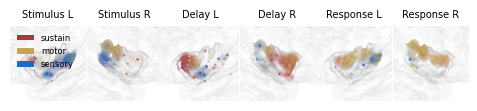

In [12]:
if "spatial_by_phase" not in globals() or "render_phase_brains_density_electrodes" not in globals():
    raise RuntimeError("Run the previous cell first (surfaces + spatial_by_phase).")

spatial_phases = [p for p in PHASES if p != "go"]
n_panels = 2 * len(spatial_phases)
fig, axes = plt.subplots(
    nrows=1,
    ncols=n_panels,
    figsize=(2.5 * n_panels * cm, 5 * cm),
)
plt.subplots_adjust(wspace=0.02)

for col, phase in enumerate(spatial_phases):
    ax_l, ax_r = axes[2 * col], axes[2 * col + 1]
    spatial = spatial_by_phase[phase]
    if spatial.empty:
        for ax in (ax_l, ax_r):
            ax.text(0.5, 0.5, f"No data ({phase})", ha="center", va="center")
            ax.axis("off")
        continue
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lh_img, rh_img, vmin, vmax = render_phase_brains_density_electrodes(spatial)
    ax_l.imshow(lh_img)
    ax_r.imshow(rh_img)
    ax_l.set_title(f"{phase.capitalize()} L", fontsize=fontsize)
    ax_r.set_title(f"{phase.capitalize()} R", fontsize=fontsize)
    ax_l.axis("off")
    ax_r.axis("off")

axes[0].legend(
    handles=[Patch(facecolor=FUNCTION_COLORS[c], label=c) for c in TRACE_CLUSTERS],
    loc="upper left",
    fontsize=fontsize - 1,
    framealpha=0.9,
    frameon=False,
)
save_svg(fig, IMG / "functional_hga_spatial_phases_density_electrodes.svg", close=False)
print("Wrote", IMG / "functional_hga_spatial_phases_density_electrodes.svg")


## Laterality

Coverage denominator is **all implanted pure AIC/PIC contacts** from Hammers bipolar parcellation (four NMF tasks, unique `subject+channel`, drop D0121) — not the packaged HGA sig-union.

Then: NMF hard labels (including unlabeled implants), soft loadings (mean / p90 / max), within-subject LI on the 10 bilateral NMF subjects, Repeat HGA traces with left solid / right dashed, and **home-phase** window-mean HGA (sensory←Stimulus, sustain←Delay, motor←Response).

Run the next cell first. The HGA overlay cell needs the earlier packaged-HGA load. Parcellation CSVs are small; the HGA overlay still belongs on a compute node if `hga` is not already in memory.


In [13]:
from src.connectivity.pairwise.config import DEFAULT_DATASETS
from src.nmf.waveform_pca import load_exclude_channels
from src.paths import nmf_assignments_path, nmf_exclude_channels_path
from scipy.stats import chi2_contingency, mannwhitneyu

EXCLUDE_SUBJECTS = {"D0121"}
LATERALITY_PHASES = ["stimulus", "delay", "response"]
UNLABELED = "unlabeled"
UNLABELED_COLOR = "#D0D0D0"
HEMI_COLORS = {"L": "#333333", "R": "#B0B0B0"}
HEMI_LABELS = {"L": "Left", "R": "Right"}
COMPOSITION_ORDER = list(CLUSTER_ORDER) + [UNLABELED]
COMPOSITION_COLORS = {**FUNCTION_COLORS, UNLABELED: UNLABELED_COLOR}


def _as_bool_mix(values: pd.Series) -> pd.Series:
    if values.dtype == bool:
        return values
    text = values.astype(str).str.strip().str.lower()
    return text.isin({"1", "true", "t", "yes"})


def load_implanted_insula() -> pd.DataFrame:
    """Unique pure AIC/PIC bipolar contacts across the four NMF tasks.

    Deduplicate ``subject+channel`` first (task order from ``DEFAULT_DATASETS``,
    skipping LexicalNoDelay), then keep Hammers ``AIC``/``PIC`` with ``mix=False``.
    """
    frames = []
    for task, bids_root in DEFAULT_DATASETS.items():
        if task == "LexicalNoDelay":
            continue
        paths = sorted(Path(bids_root).glob("derivatives/parcellation/sub-*/bipolar/sub-*_hammers.csv"))
        if not paths:
            print(f"warning: no Hammers parcellation CSVs for {task} under {bids_root}")
            continue
        for path in paths:
            df = pd.read_csv(path, usecols=lambda c: c in {"name", "roi", "hemi", "mix"})
            if "name" not in df.columns or "roi" not in df.columns or "hemi" not in df.columns:
                continue
            df = df.copy()
            df["subject"] = path.parent.parent.name.removeprefix("sub-")
            df["task"] = task
            df["channel"] = df["name"].astype(str)
            frames.append(df)
    if not frames:
        raise FileNotFoundError("No parcellation CSVs found in DEFAULT_DATASETS")
    allc = pd.concat(frames, ignore_index=True)
    if "mix" in allc.columns:
        allc["mix"] = _as_bool_mix(allc["mix"].fillna(False))
    else:
        allc["mix"] = False
    allc["hemi"] = allc["hemi"].astype(str).str.upper().str[0]
    uniq = allc.drop_duplicates(["subject", "channel"], keep="first")
    uniq = uniq[~uniq["subject"].isin(EXCLUDE_SUBJECTS)]
    implanted = uniq[uniq["roi"].astype(str).isin({"AIC", "PIC"}) & ~uniq["mix"]].copy()
    implanted = implanted[implanted["hemi"].isin(["L", "R"])]
    return implanted[["subject", "channel", "roi", "hemi"]].reset_index(drop=True)


drop = load_exclude_channels(nmf_exclude_channels_path())
assign = pd.read_csv(nmf_assignments_path())
assign["channel"] = assign["channel"].astype(str)
assign = assign[~assign["channel"].isin(drop)].copy()
assign = assign[~assign["subject"].astype(str).isin(EXCLUDE_SUBJECTS)].copy()
assign["hemi"] = assign["hemi"].astype(str).str.upper().str[0]
assign["functional_cluster"] = assign["functional_cluster"].astype(str)
assign = assign[assign["hemi"].isin(["L", "R"])].reset_index(drop=True)

implanted = load_implanted_insula()
nmf_keys = set(zip(assign["subject"].astype(str), assign["channel"].astype(str)))
implanted["in_nmf"] = [
    (str(s), str(c)) in nmf_keys for s, c in zip(implanted["subject"], implanted["channel"])
]
label_map = assign.set_index(["subject", "channel"])["functional_cluster"]
implanted["functional_cluster"] = [
    label_map.get((str(s), str(c)), UNLABELED)
    for s, c in zip(implanted["subject"], implanted["channel"])
]
implanted.loc[~implanted["in_nmf"], "functional_cluster"] = UNLABELED

n_imp_l = int((implanted["hemi"] == "L").sum())
n_imp_r = int((implanted["hemi"] == "R").sum())
p_left_implant = n_imp_l / len(implanted)
coverage = (
    pd.DataFrame(
        {
            "set": ["Implanted", "Implanted", "NMF", "NMF"],
            "hemi": ["L", "R", "L", "R"],
            "n": [
                n_imp_l,
                n_imp_r,
                int((assign["hemi"] == "L").sum()),
                int((assign["hemi"] == "R").sum()),
            ],
        }
    )
)
composition = (
    implanted.groupby(["hemi", "functional_cluster"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=["L", "R"], columns=COMPOSITION_ORDER, fill_value=0)
)
composition_frac = composition.div(composition.sum(axis=1), axis=0)

loading_long = assign.melt(
    id_vars=["channel", "hemi"],
    value_vars=[f"loading_{c}" for c in CLUSTER_ORDER],
    var_name="cluster",
    value_name="loading",
)
loading_long["cluster"] = loading_long["cluster"].str.replace("loading_", "", regex=False)

loading_stats = []
for cluster in CLUSTER_ORDER:
    for hemi in ("L", "R"):
        vals = assign.loc[assign["hemi"] == hemi, f"loading_{cluster}"]
        loading_stats.append(
            {
                "cluster": cluster,
                "hemi": hemi,
                "n": int(vals.size),
                "mean": float(vals.mean()),
                "p90": float(vals.quantile(0.9)),
                "max": float(vals.max()),
            }
        )
loading_stats = pd.DataFrame(loading_stats)

bilateral_subjects = []
for subject, grp in assign.groupby("subject"):
    hemis = set(grp["hemi"])
    if hemis != {"L", "R"}:
        continue
    for cluster in CLUSTER_ORDER:
        left = grp.loc[grp["hemi"] == "L", f"loading_{cluster}"].mean()
        right = grp.loc[grp["hemi"] == "R", f"loading_{cluster}"].mean()
        denom = left + right
        li = np.nan if denom == 0 else (left - right) / denom
        bilateral_subjects.append(
            {"subject": subject, "cluster": cluster, "LI": li, "left": left, "right": right}
        )
subject_li = pd.DataFrame(bilateral_subjects)

print("implanted AIC/PIC:", dict(implanted["hemi"].value_counts()), "n=", len(implanted))
print("NMF electrodes:", dict(assign["hemi"].value_counts()), "n=", len(assign))
print(f"implant p_L = {p_left_implant:.3f}  ({n_imp_l}/{len(implanted)})")
print(
    "inclusion L/R:",
    (
        coverage.loc[coverage["set"] == "NMF", "n"].to_numpy()
        / coverage.loc[coverage["set"] == "Implanted", "n"].to_numpy()
    ).round(3),
)
print("composition counts:\n", composition)
print("composition fractions:\n", composition_frac.round(3))
print("bilateral NMF subjects:", subject_li["subject"].nunique())

ct = pd.crosstab(implanted["functional_cluster"], implanted["hemi"]).reindex(
    COMPOSITION_ORDER, fill_value=0
)
chi2, p_chi, _, _ = chi2_contingency(ct)
print(f"cluster × hemi χ² (implanted, incl. unlabeled) p={p_chi:.3f}")
for cluster in CLUSTER_ORDER:
    left = assign.loc[assign["hemi"] == "L", f"loading_{cluster}"]
    right = assign.loc[assign["hemi"] == "R", f"loading_{cluster}"]
    _, p_mw = mannwhitneyu(left, right, alternative="two-sided")
    li_mean = (left.mean() - right.mean()) / (left.mean() + right.mean())
    print(f"  {cluster} mean loading LI={li_mean:+.3f}  MW p={p_mw:.3f}")


implanted AIC/PIC: {'L': 281, 'R': 179} n= 460
NMF electrodes: {'L': 157, 'R': 98} n= 255
implant p_L = 0.611  (281/460)
inclusion L/R: [0.559 0.547]
composition counts:
 functional_cluster  sustain  motor  sensory  unlabeled
hemi                                                  
L                        48     84       23        126
R                        24     58       15         82
composition fractions:
 functional_cluster  sustain  motor  sensory  unlabeled
hemi                                                  
L                     0.171  0.299    0.082      0.448
R                     0.134  0.324    0.084      0.458
bilateral NMF subjects: 10
cluster × hemi χ² (implanted, incl. unlabeled) p=0.754
  sustain mean loading LI=+0.102  MW p=0.043
  motor mean loading LI=-0.062  MW p=0.085
  sensory mean loading LI=+0.067  MW p=0.200


Subject-level laterality index on the bilateral NMF subjects only. Each point is one subject; diamonds are the mean. Do not treat this as a hemisphere-max or implant-count result.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/laterality_subject_li.svg
          mean  median
cluster               
motor    0.176   0.108
sensory  0.078   0.387
sustain  0.140   0.059


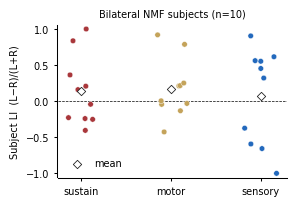

In [15]:
fig, ax = plt.subplots(figsize=(7.5 * cm, 5 * cm))
sns.stripplot(
    data=subject_li,
    x="cluster",
    y="LI",
    order=list(CLUSTER_ORDER),
    hue="cluster",
    hue_order=list(CLUSTER_ORDER),
    palette=FUNCTION_COLORS,
    jitter=0.18,
    size=4,
    linewidth=0.3,
    edgecolor="white",
    legend=False,
    ax=ax,
)
means = subject_li.groupby("cluster")["LI"].mean().reindex(CLUSTER_ORDER)
ax.scatter(
    np.arange(len(CLUSTER_ORDER)),
    means.to_numpy(),
    marker="D",
    s=18,
    color="white",
    edgecolor="#222222",
    linewidth=0.6,
    zorder=3,
    label="mean",
)
ax.axhline(0, color="k", linestyle="--", linewidth=0.5)
ax.set_xlabel("")
ax.set_ylabel("Subject LI  (L−R)/(L+R)", fontsize=fontsize)
ax.set_title(f"Bilateral NMF subjects (n={subject_li['subject'].nunique()})", fontsize=fontsize)
ax.set_ylim(-1.05, 1.05)
ax.legend(frameon=False, fontsize=fontsize)
style_ax(ax, trim=False)
save_svg(fig, IMG / "laterality_subject_li.svg", close=False)
print("Wrote", IMG / "laterality_subject_li.svg")
print(subject_li.groupby("cluster")["LI"].agg(["mean", "median"]).round(3))


Repeat HGA traces by cluster and hemisphere (Stimulus, Delay, Response; no Go). Same `FUNCTION_COLORS`; left solid, right dashed. Needs the earlier packaged-HGA load.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/functional_hga_traces_hemi.svg
hemi            L   R
cluster_label        
motor          84  58
sensory        24  16
sustain        51  26


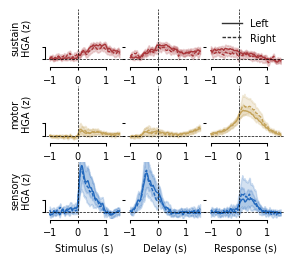

In [16]:
if "hga" not in globals():
    raise RuntimeError("Run the packaged-HGA load cell first (compute node).")

hga_lat = hga.copy()
if "hemi" not in hga_lat.columns or hga_lat["hemi"].isna().all():
    hga_lat["hemi"] = hga_lat["channel"].map(assign.set_index("channel")["hemi"])
hga_lat["hemi"] = hga_lat["hemi"].astype(str).str.upper().str[0]
hga_lat = hga_lat[hga_lat["hemi"].isin(["L", "R"])]
if "cluster_label" not in hga_lat.columns:
    hga_lat["cluster_label"] = hga_lat["functional_cluster"].astype(str)

clusters = [c for c in CLUSTER_ORDER if c in set(hga_lat["cluster_label"].astype(str))]
fig, axes = plt.subplots(
    nrows=len(clusters),
    ncols=len(LATERALITY_PHASES),
    figsize=(2.6 * len(LATERALITY_PHASES) * cm, 2.3 * len(clusters) * cm),
    sharey=True,
)
plt.subplots_adjust(wspace=0.05, hspace=0.35)

from matplotlib.lines import Line2D

for i, cluster in enumerate(clusters):
    for j, phase in enumerate(LATERALITY_PHASES):
        ax = axes[i, j]
        sub = hga_lat[(hga_lat["cluster_label"] == cluster) & (hga_lat["phase"] == phase)]
        sns.lineplot(
            data=sub,
            x="time",
            y="value",
            hue="hemi",
            hue_order=["L", "R"],
            style="hemi",
            style_order=["L", "R"],
            dashes={"L": "", "R": (2.5, 1.2)},
            palette={"L": FUNCTION_COLORS[cluster], "R": FUNCTION_COLORS[cluster]},
            estimator="mean",
            errorbar=("ci", 95),
            lw=1,
            legend=False,
            ax=ax,
        )
        ax.axvline(x=0, color="k", linestyle="--", linewidth=0.5)
        ax.axhline(y=0, color="k", linestyle="--", linewidth=0.5)
        style_ax(ax, trim=True)
        ax.set_ylim(-0.1, 0.8)
        ax.set_xlabel(f"{phase.capitalize()} (s)" if i == len(clusters) - 1 else "", fontsize=fontsize)
        if j == 0:
            ax.set_ylabel(f"{cluster}\nHGA (z)", fontsize=fontsize)
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])
            ax.spines["left"].set_visible(False)

axes[0, -1].legend(
    handles=[
        Line2D([0], [0], color="#333333", lw=1, linestyle="-", label="Left"),
        Line2D([0], [0], color="#333333", lw=1, linestyle=(0, (2.5, 1.2)), label="Right"),
    ],
    frameon=False,
    fontsize=fontsize,
    loc="upper right",
)
save_svg(fig, IMG / "functional_hga_traces_hemi.svg", close=False)
print("Wrote", IMG / "functional_hga_traces_hemi.svg")
print(hga_lat.groupby(["cluster_label", "hemi"])["channel"].nunique().unstack())


## Phase-matched laterality

Use the phase where that component should fire, not electrode counts or density area.

| component | phase | window |
|---|---|---|
| sensory | Stimulus | 0–0.5 s |
| sustain | Delay | 0–1.0 s |
| motor | Response | 0–0.5 s |

Each electrode contributes its window-mean Repeat HGA. The figure is a **L–R seesaw**: subject-equalized $\mathrm{LI}=(\mu_L-\mu_R)/(\mu_L+\mu_R)$, left-dominant on the left. Error bars are 95% subject-bootstrap CIs. Printed controls use the same window on the other two clusters.


phase-matched window-mean HGA (that cluster only)
  sensory  stimulus (0,0.5)s  n=24/15  mean L/R=0.624/0.301  LI=+0.350  MW p=0.034
  sustain  delay (0,1)s  n=49/25  mean L/R=0.158/0.126  LI=+0.113  MW p=0.411
  motor    response (0,0.5)s  n=84/58  mean L/R=0.364/0.465  LI=-0.121  MW p=0.182

same window, other clusters (control)
  not-sensory  stimulus  n=133/83  mean L/R=0.098/0.071  LI=+0.161  MW p=0.202
  not-sustain  delay  n=108/73  mean L/R=0.045/0.023  LI=+0.323  MW p=0.372
  not-motor    response  n=73/40  mean L/R=0.136/0.096  LI=+0.170  MW p=0.469

subject-equalized LI (figure)
cluster    phase  n_elec_L  n_elec_R  n_subj_L  n_subj_R  mean_L  mean_R     LI  ci_lo  ci_hi  boot_p
sensory stimulus        24        15        13         9   0.534   0.383  0.164 -0.312  0.688   0.495
sustain    delay        49        25        23        14   0.158   0.112  0.170 -0.057  0.387   0.140
  motor response        84        58        37        24   0.415   0.486 -0.079 -0.334  0.191   0

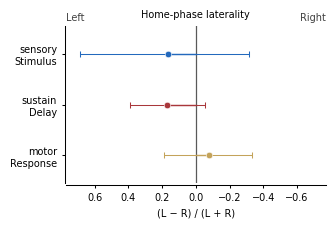

In [ ]:
if "hga" not in globals():
    raise RuntimeError("Run the packaged-HGA load cell first.")

from scipy.stats import mannwhitneyu

HOME_PHASE = {
    "sensory": ("stimulus", 0.0, 0.5),
    "sustain": ("delay", 0.0, 1.0),
    "motor": ("response", 0.0, 0.5),
}
PHASE_CLUSTER_ORDER = ("sensory", "sustain", "motor")

hga_home = hga.copy()
if "assign" in globals():
    hga_home["hemi"] = hga_home["channel"].map(assign.set_index("channel")["hemi"])
elif "hemi" not in hga_home.columns or hga_home["hemi"].isna().all():
    raise RuntimeError("Need assign or hemi on hga.")
hga_home["hemi"] = hga_home["hemi"].astype(str).str.upper().str[0]
hga_home = hga_home[hga_home["hemi"].isin(["L", "R"])]
if "cluster_label" not in hga_home.columns:
    hga_home["cluster_label"] = hga_home["functional_cluster"].astype(str)

rows = []
for cluster, (phase, t0, t1) in HOME_PHASE.items():
    win = hga_home[
        (hga_home["phase"] == phase)
        & (hga_home["time"] > t0)
        & (hga_home["time"] < t1)
    ]
    elec = (
        win.groupby(["channel", "hemi", "cluster_label", "subject"], as_index=False)
        .agg(HGA=("value", "mean"))
    )
    elec["home_cluster"] = cluster
    elec["home_phase"] = phase
    rows.append(elec)
home_hga = pd.concat(rows, ignore_index=True)
matched = home_hga[home_hga["cluster_label"] == home_hga["home_cluster"]].copy()
matched.to_csv(RESULTS / "laterality_home_phase_electrodes.csv", index=False)

print("phase-matched window-mean HGA (that cluster only)")
for cluster in PHASE_CLUSTER_ORDER:
    phase, t0, t1 = HOME_PHASE[cluster]
    sub = matched[matched["home_cluster"] == cluster]
    left = sub.loc[sub["hemi"] == "L", "HGA"]
    right = sub.loc[sub["hemi"] == "R", "HGA"]
    li = (left.mean() - right.mean()) / (left.mean() + right.mean())
    _, p = mannwhitneyu(left, right, alternative="two-sided")
    print(
        f"  {cluster:8s} {phase} ({t0:g},{t1:g})s  "
        f"n={left.size}/{right.size}  mean L/R={left.mean():.3f}/{right.mean():.3f}  "
        f"LI={li:+.3f}  MW p={p:.3f}"
    )

print("\nsame window, other clusters (control)")
for cluster in PHASE_CLUSTER_ORDER:
    phase, t0, t1 = HOME_PHASE[cluster]
    sub = home_hga[
        (home_hga["home_cluster"] == cluster)
        & (home_hga["cluster_label"] != cluster)
    ]
    left = sub.loc[sub["hemi"] == "L", "HGA"]
    right = sub.loc[sub["hemi"] == "R", "HGA"]
    if left.empty or right.empty:
        continue
    li = (left.mean() - right.mean()) / (left.mean() + right.mean())
    _, p = mannwhitneyu(left, right, alternative="two-sided")
    print(
        f"  not-{cluster:8s} {phase}  n={left.size}/{right.size}  "
        f"mean L/R={left.mean():.3f}/{right.mean():.3f}  LI={li:+.3f}  MW p={p:.3f}"
    )

if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))
import importlib
import plot_laterality_seesaw
importlib.reload(plot_laterality_seesaw)
from plot_laterality_seesaw import plot_seesaw, summarize

seesaw = summarize(matched)
print("\nsubject-equalized LI (figure)")
print(seesaw.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
seesaw.to_csv(RESULTS / "laterality_home_phase_seesaw.csv", index=False)
plot_seesaw(seesaw, IMG / "laterality_home_phase_hga.svg", close=False)
print("Wrote", IMG / "laterality_home_phase_hga.svg")

## L vs R pointplots

Same x-axis on five panels: Left, Right. Points sit on those ticks (no dodge).

- **Sampled electrodes** is coverage only: all implanted AIC/PIC contacts, not split by cluster.
- **Cluster electrodes** is how many NMF-labeled contacts fall in each functional cluster.
- **Cluster rate** is that count divided by sampled electrodes in the same hemisphere.
- **Home-phase HGA** is physiology (subject means, 95% CI), hue by cluster.
- **Winner NMF weight** is that electrode's weight on the component it was assigned to (subject means, 95% CI).

A downward slope is left stronger; upward is right stronger; parallel lines are amplitude differences without laterality.


Wrote /hpc/group/coganlab/nanlinshi/insula-functional/img/nmf/laterality_pointplot.svg
sampled AIC/PIC:
 {'L': 281, 'R': 179}
cluster electrodes:
 hemi      L   R
cluster        
sensory  24  15
sustain  49  25
motor    84  58
cluster rate (n / sampled):
 hemi         L      R
cluster              
sensory  0.085  0.084
sustain  0.174  0.140
motor    0.299  0.324
subject-mean HGA:
 hemi         L      R
cluster              
sensory  0.534  0.383
sustain  0.158  0.112
motor    0.415  0.486
subject-mean winner weight:
 hemi         L      R
cluster              
sensory  0.655  0.631
sustain  0.641  0.588
motor    0.710  0.786


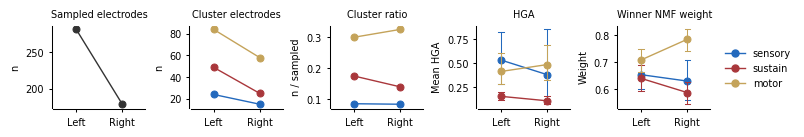

In [35]:
from matplotlib.lines import Line2D
from src.nmf.waveform_pca import load_exclude_channels
from src.paths import nmf_assignments_path, nmf_exclude_channels_path

PHASE_CLUSTER_ORDER = ("sensory", "sustain", "motor")
HEMI_ORDER = ("L", "R")
HEMI_LABELS = {"L": "Left", "R": "Right"}
POINT_KWS = dict(
    order=list(HEMI_ORDER),
    dodge=False,
    markersize=5,
    linewidth=1.0,
    capsize=0.12,
    err_kws={"linewidth": 0.75},
)
CLUSTER_KWS = dict(
    hue="cluster",
    hue_order=list(PHASE_CLUSTER_ORDER),
    palette=FUNCTION_COLORS,
    legend=False,
    **POINT_KWS,
)


def _laterality_assign(frame: pd.DataFrame) -> pd.DataFrame:
    drop = load_exclude_channels(nmf_exclude_channels_path())
    out = frame.copy()
    out["channel"] = out["channel"].astype(str)
    out = out[~out["channel"].isin(drop)]
    out = out[~out["subject"].astype(str).isin({"D0121"})]
    out["hemi"] = out["hemi"].astype(str).str.upper().str[0]
    out["functional_cluster"] = out["functional_cluster"].astype(str)
    out = out[out["hemi"].isin(HEMI_ORDER)]
    out = out[out["functional_cluster"].isin(PHASE_CLUSTER_ORDER)]
    return out.reset_index(drop=True)


if "assign" in globals():
    assign_lr = _laterality_assign(assign)
else:
    assign_lr = _laterality_assign(pd.read_csv(nmf_assignments_path()))

if "matched" in globals():
    matched_lr = matched.copy()
else:
    matched_path = RESULTS / "laterality_home_phase_electrodes.csv"
    if not matched_path.is_file():
        raise FileNotFoundError(
            "Run the phase-matched laterality cell first, or keep "
            f"{matched_path.name}."
        )
    matched_lr = pd.read_csv(matched_path)

matched_lr["hemi"] = matched_lr["hemi"].astype(str).str.upper().str[0]
matched_lr = matched_lr[matched_lr["hemi"].isin(HEMI_ORDER)]
matched_lr = matched_lr[matched_lr["home_cluster"].isin(PHASE_CLUSTER_ORDER)]

if "implanted" in globals():
    implanted_lr = implanted[implanted["hemi"].isin(HEMI_ORDER)]
elif "load_implanted_insula" in globals():
    implanted_lr = load_implanted_insula()
    implanted_lr = implanted_lr[implanted_lr["hemi"].isin(HEMI_ORDER)]
else:
    raise RuntimeError("Run the laterality loading cell first (needs implanted).")

n_sample = (
    implanted_lr.groupby("hemi", as_index=False)
    .size()
    .rename(columns={"size": "n"})
)
n_cluster = (
    assign_lr.groupby(["functional_cluster", "hemi"], as_index=False)
    .size()
    .rename(columns={"functional_cluster": "cluster", "size": "n"})
)
n_imp = n_sample.set_index("hemi")["n"]
n_rate = n_cluster.copy()
n_rate["rate"] = n_rate["n"] / n_rate["hemi"].map(n_imp)
subj_hga = (
    matched_lr.groupby(["home_cluster", "hemi", "subject"], as_index=False)["HGA"]
    .mean()
    .rename(columns={"home_cluster": "cluster"})
)
assign_lr = assign_lr.copy()
assign_lr["winner_loading"] = [
    float(row[f"loading_{row['functional_cluster']}"])
    for row in assign_lr.to_dict("records")
]
subj_load = (
    assign_lr.groupby(["functional_cluster", "hemi", "subject"], as_index=False)[
        "winner_loading"
    ]
    .mean()
    .rename(columns={"functional_cluster": "cluster"})
)

fig, axes = plt.subplots(1, 5, figsize=(18 * cm, 3.2 * cm), constrained_layout=True)

sns.pointplot(
    data=n_sample,
    x="hemi",
    y="n",
    color="#333333",
    errorbar=None,
    ax=axes[0],
    **POINT_KWS,
)
sns.pointplot(
    data=n_cluster,
    x="hemi",
    y="n",
    errorbar=None,
    ax=axes[1],
    **CLUSTER_KWS,
)
sns.pointplot(
    data=n_rate,
    x="hemi",
    y="rate",
    errorbar=None,
    ax=axes[2],
    **CLUSTER_KWS,
)
sns.pointplot(
    data=subj_hga,
    x="hemi",
    y="HGA",
    errorbar=("ci", 95),
    ax=axes[3],
    **CLUSTER_KWS,
)
sns.pointplot(
    data=subj_load,
    x="hemi",
    y="winner_loading",
    errorbar=("ci", 95),
    ax=axes[4],
    **CLUSTER_KWS,
)

axes[0].set_title("Sampled electrodes", fontsize=fontsize)
axes[1].set_title("Cluster electrodes", fontsize=fontsize)
axes[2].set_title("Cluster ratio", fontsize=fontsize)
axes[3].set_title("HGA", fontsize=fontsize)
axes[4].set_title("Winner NMF weight", fontsize=fontsize)
axes[0].set_ylabel("n", fontsize=fontsize)
axes[1].set_ylabel("n", fontsize=fontsize)
axes[2].set_ylabel("n / sampled", fontsize=fontsize)
axes[3].set_ylabel("Mean HGA", fontsize=fontsize)
axes[4].set_ylabel("Weight", fontsize=fontsize)
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks([0, 1])
    ax.set_xticklabels([HEMI_LABELS[h] for h in HEMI_ORDER])
    style_ax(ax, trim=False)
handles = [
    Line2D(
        [0],
        [0],
        color=FUNCTION_COLORS[c],
        marker="o",
        markersize=5,
        linewidth=1.0,
        label=c,
    )
    for c in PHASE_CLUSTER_ORDER
]
for ax in axes:
    if ax.legend_ is not None:
        ax.legend_.remove()
fig.legend(
    handles,
    PHASE_CLUSTER_ORDER,
    frameon=False,
    fontsize=fontsize,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    borderaxespad=0,
)

save_svg(fig, IMG / "laterality_pointplot.svg", close=False)
print("Wrote", IMG / "laterality_pointplot.svg")
print("sampled AIC/PIC:\n", n_sample.set_index("hemi")["n"].reindex(HEMI_ORDER).to_dict())
print(
    "cluster electrodes:\n",
    n_cluster.pivot(index="cluster", columns="hemi", values="n").reindex(
        PHASE_CLUSTER_ORDER
    ),
)
print(
    "cluster rate (n / sampled):\n",
    n_rate.pivot(index="cluster", columns="hemi", values="rate")
    .reindex(PHASE_CLUSTER_ORDER)
    .round(3),
)
print(
    "subject-mean HGA:\n",
    subj_hga.groupby(["cluster", "hemi"])["HGA"]
    .mean()
    .unstack()
    .reindex(index=PHASE_CLUSTER_ORDER, columns=list(HEMI_ORDER))
    .round(3),
)
print(
    "subject-mean winner weight:\n",
    subj_load.groupby(["cluster", "hemi"])["winner_loading"]
    .mean()
    .unstack()
    .reindex(index=PHASE_CLUSTER_ORDER, columns=list(HEMI_ORDER))
    .round(3),
)